1. Data Exploration:

In [41]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings 
warnings.filterwarnings("ignore")

In [2]:
df=pd.read_csv('diabetes.csv')
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [3]:
df.shape

(768, 9)

In [4]:
df.size

6912

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [6]:
df.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

In [7]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [8]:
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(0)

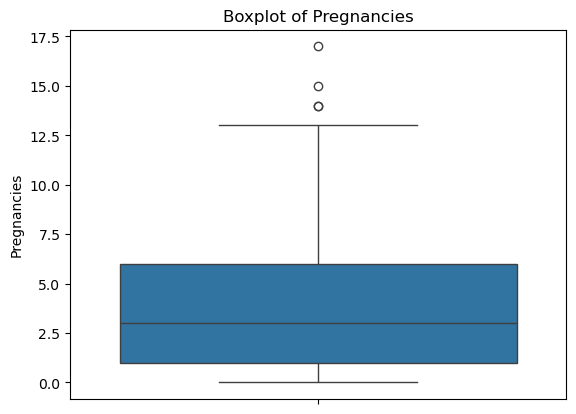

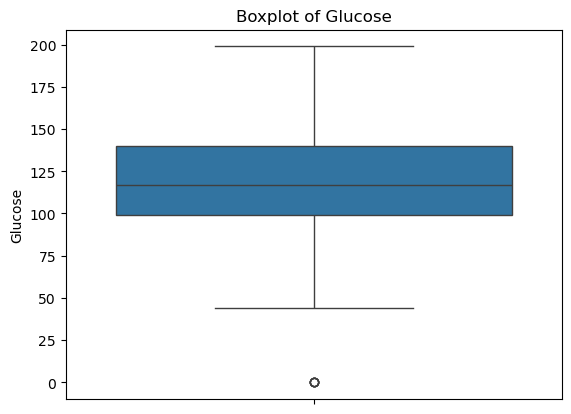

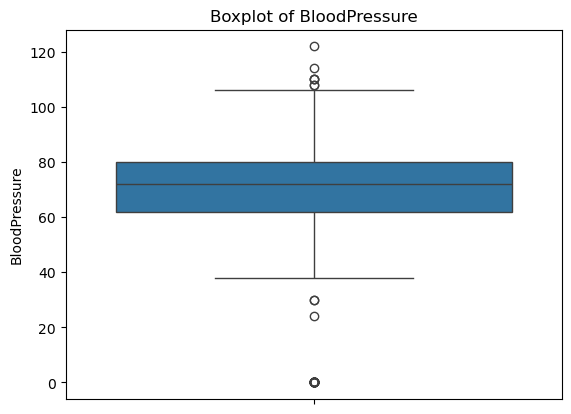

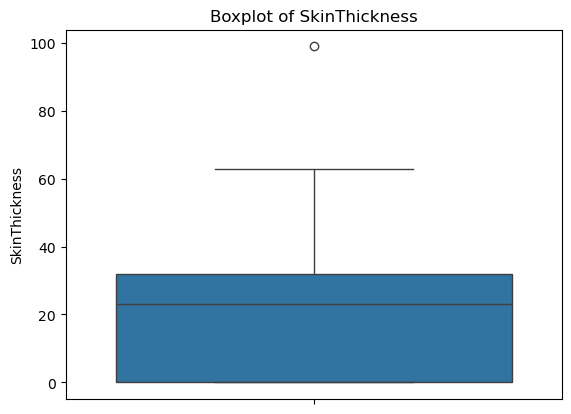

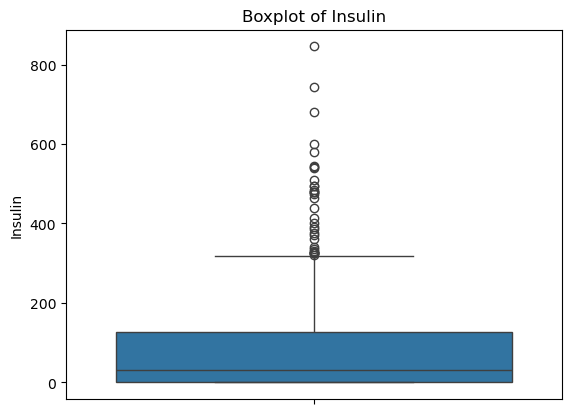

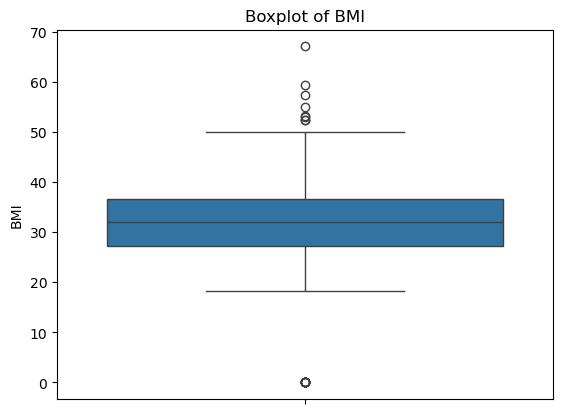

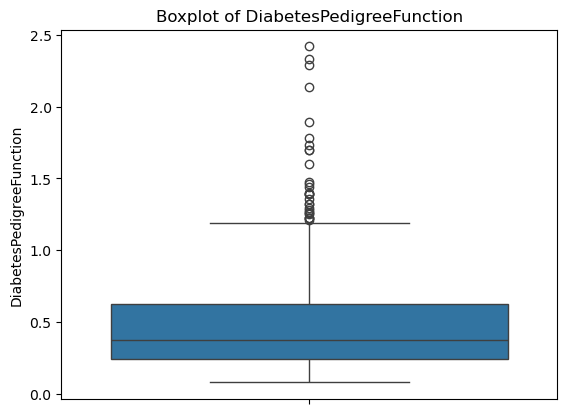

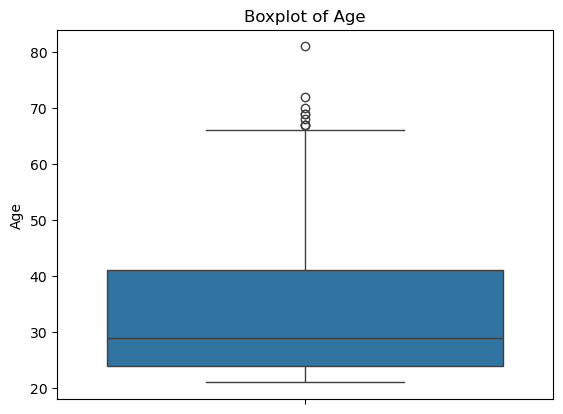

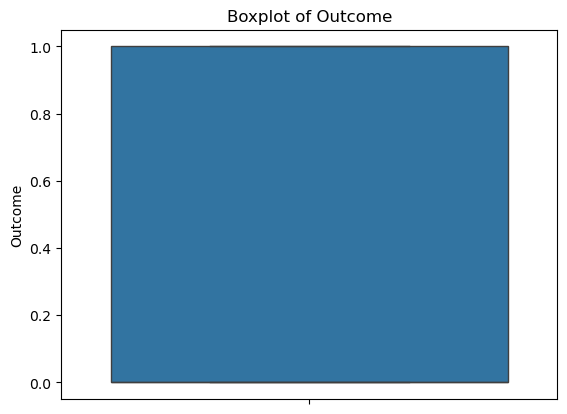

In [10]:
for col in df.select_dtypes(include=['int','float']).columns:
    sns.boxplot(df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

In [11]:
for i in df.select_dtypes(include=['int','float']).columns:
    q1=df[i].quantile(0.25)
    q3=df[i].quantile(0.75)
    iqr=q3-q1
    lower=q1-1.5*iqr
    upper=q3+1.5*iqr
    df[i]=df[i].clip(lower,upper)

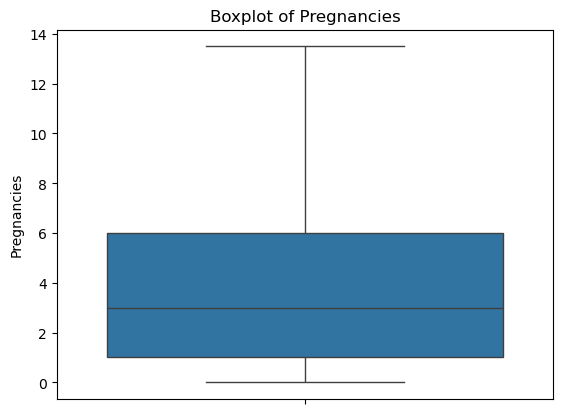

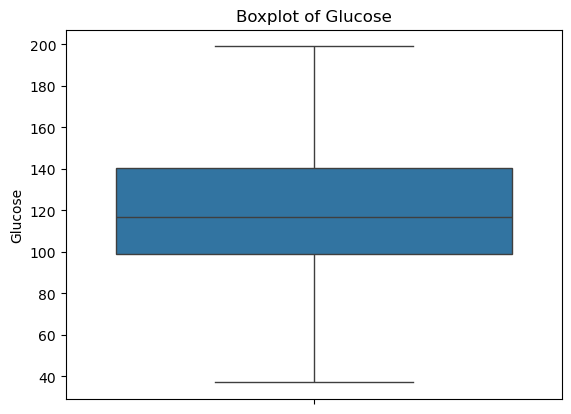

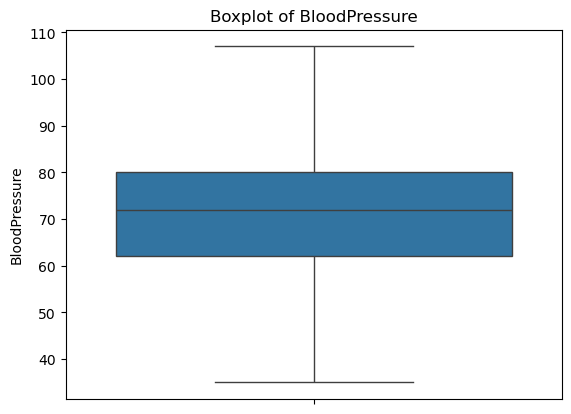

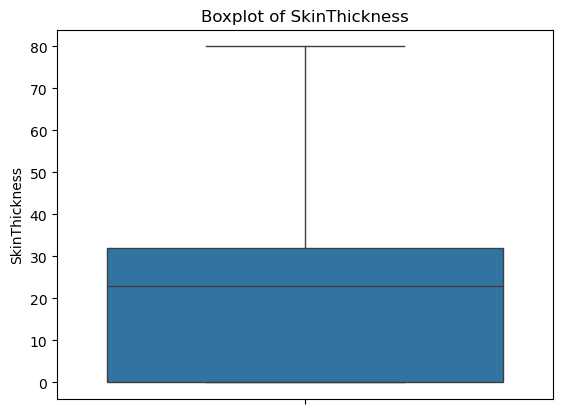

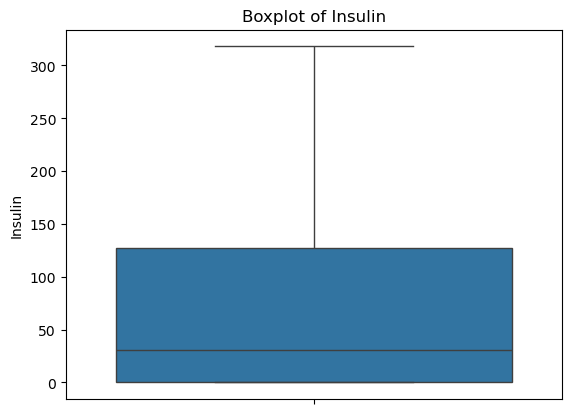

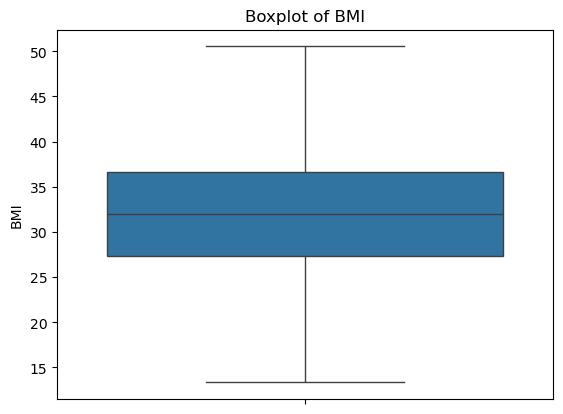

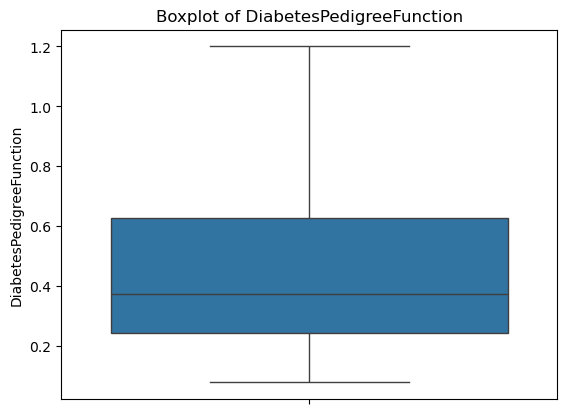

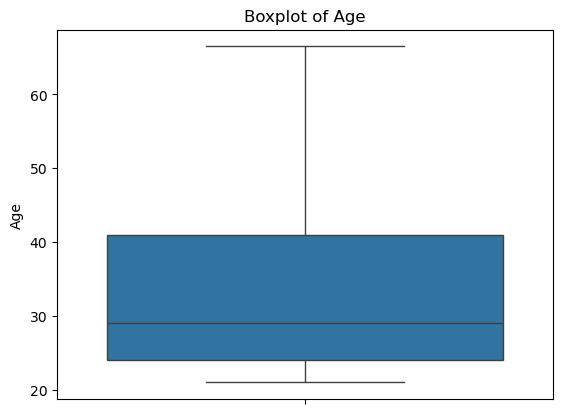

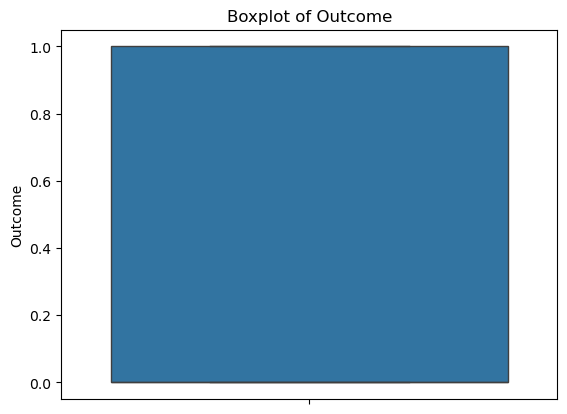

In [12]:
for col in df.select_dtypes(include=['int','float']).columns:
    sns.boxplot(df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

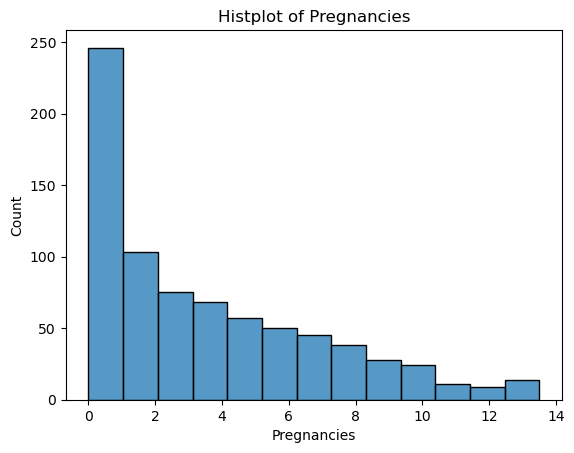

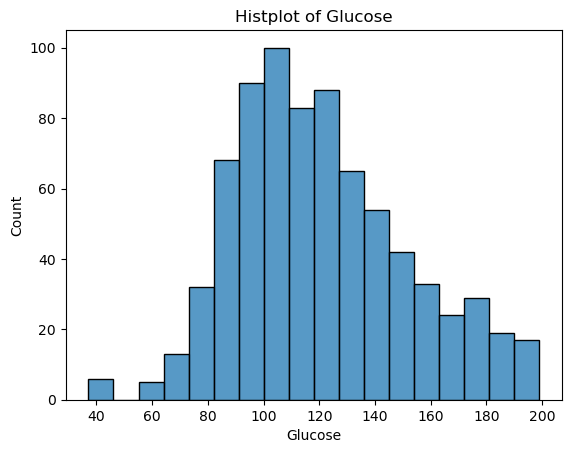

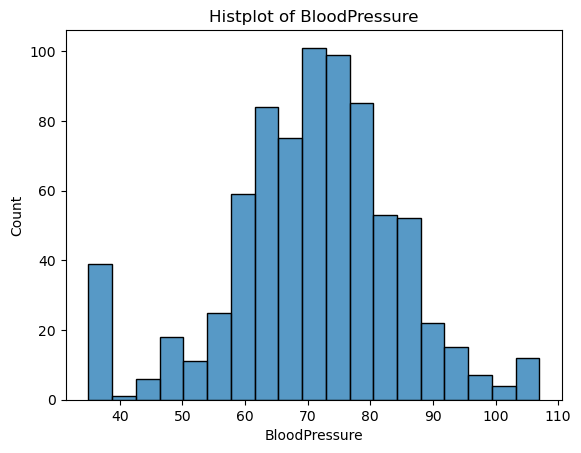

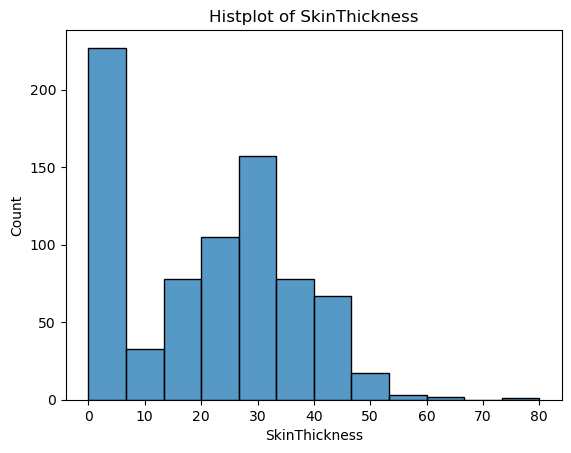

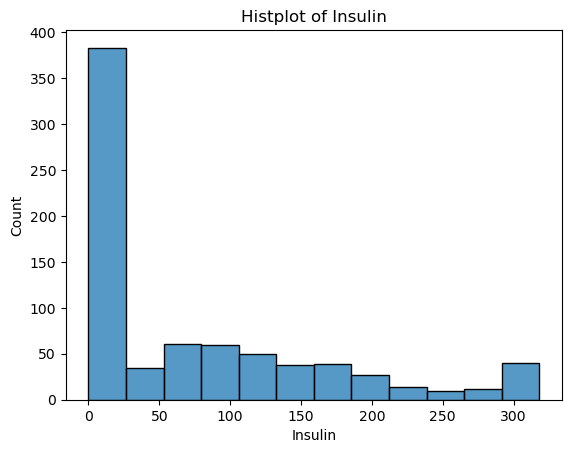

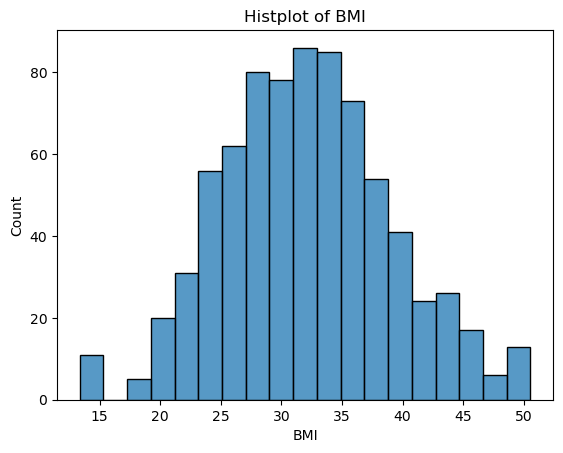

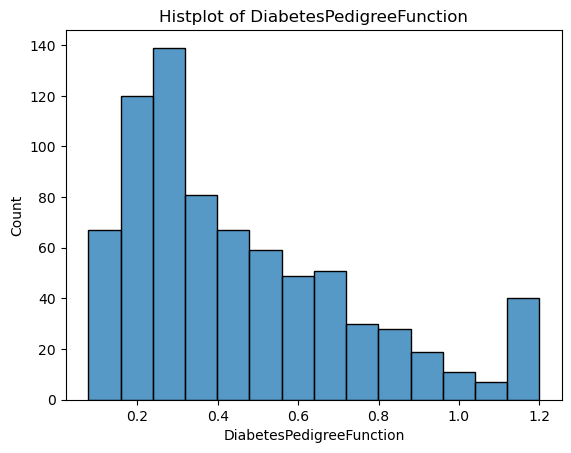

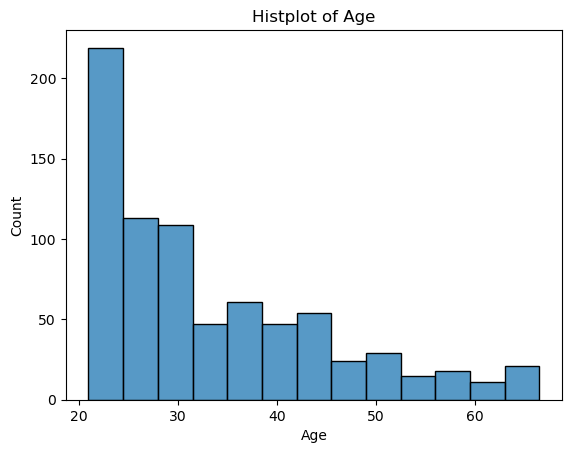

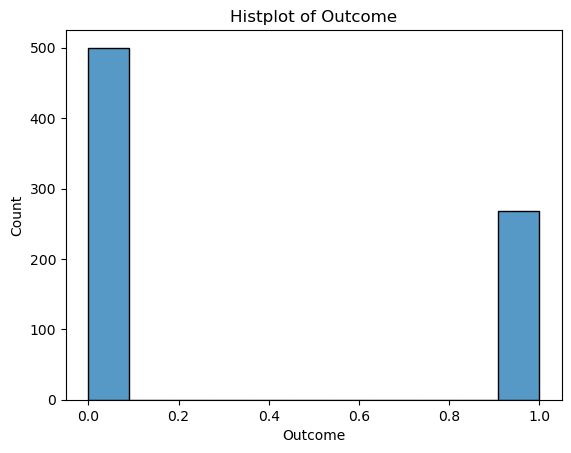

In [13]:
for col in df.select_dtypes(include=['int','float']).columns:
    sns.histplot(df[col])
    plt.title(f"Histplot of {col}")
    plt.show()

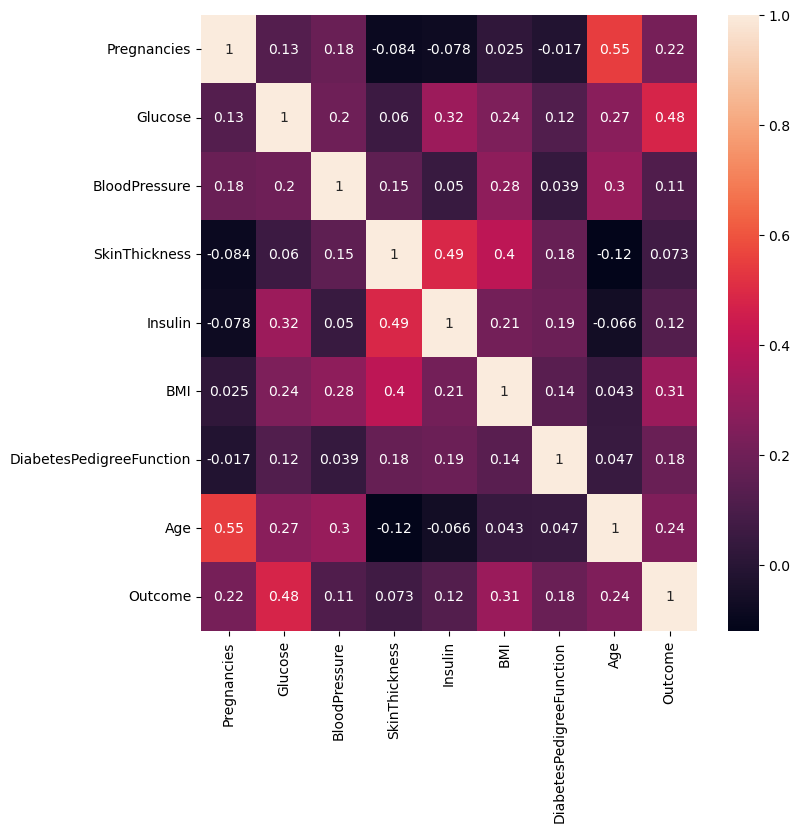

In [14]:
plt.figure(figsize=(8,8))
sns.heatmap(df.corr(numeric_only=True),annot=True)
plt.show()

In [15]:
cols=['Glucose','BloodPressure','SkinThickness','Insulin','BMI']
df[cols]=df[cols].replace(0,np.nan)

In [21]:
#2. Data Preprocessing:
#There are no missing values to be fiiled or imputed.
df.isnull().sum()

Pregnancies                   0
Glucose                       0
BloodPressure                 0
SkinThickness               227
Insulin                     374
BMI                           0
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64

In [23]:
from sklearn.impute import SimpleImputer
cols=['Glucose','BloodPressure','SkinThickness','Insulin','BMI']
imputer=SimpleImputer(strategy='median')
df[cols]=imputer.fit_transform(df[cols])

In [24]:
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [17]:
#There are no categorical columns to be encoded.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    float64
 1   Glucose                   768 non-null    float64
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             541 non-null    float64
 4   Insulin                   394 non-null    float64
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    float64
 8   Outcome                   768 non-null    int64  
dtypes: float64(7), int64(2)
memory usage: 54.1 KB


In [25]:
#3. Model Building:
x=df.drop(columns=['Outcome'])
y=df['Outcome']

In [26]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=60)

In [33]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
x_train=scaler.fit_transform(x_train)
x_test=scaler.transform(x_test)

In [34]:
#4. Model Evaluation:
from sklearn.linear_model import LogisticRegression
lr=LogisticRegression()
lr.fit(x_train,y_train)
pred=lr.predict(x_train)
pred
from sklearn.metrics import *
print("Accuracy Score is:",accuracy_score(y_train,pred))
print("Precision Score is:",precision_score(y_train,pred))
print("Recall Score is:",recall_score(y_train,pred))
print("f1 score is:",f1_score(y_train,pred))

Accuracy Score is: 0.7752442996742671
Precision Score is: 0.7283236994219653
Recall Score is: 0.5806451612903226
f1 score is: 0.6461538461538462


In [35]:
sigmoid=lr.predict_proba(x_test)[:,1]

In [36]:
from sklearn.metrics import roc_auc_score,roc_curve
auc_score=roc_auc_score(y_test,sigmoid)
print("roc_auc score is:",auc_score)

roc_auc score is: 0.8528459927660385


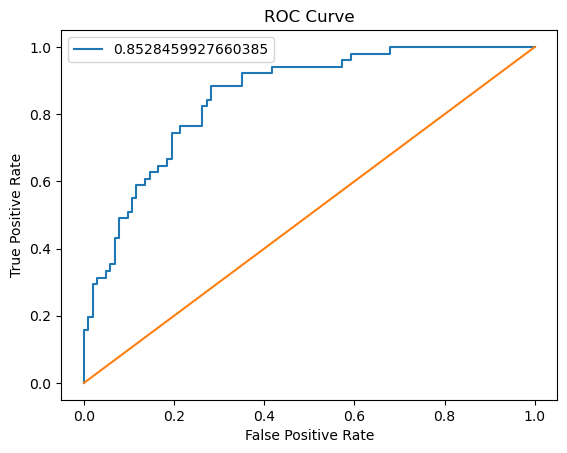

In [37]:
fpr,tpr,thr=roc_curve(y_test,sigmoid)
plt.plot(fpr,tpr,label=f'{auc_score}')
plt.plot([0,1])
plt.title('ROC Curve')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

In [38]:
#5. Interpretation:
coef_df=pd.DataFrame({'Feature':x.columns,
                      'Coefficient':lr.coef_[0]})
coef_df.sort_values('Coefficient',ascending=False,inplace=True)
print(coef_df)

                    Feature  Coefficient
1                   Glucose     1.085031
5                       BMI     0.620776
0               Pregnancies     0.315634
6  DiabetesPedigreeFunction     0.241915
7                       Age     0.178444
3             SkinThickness     0.117652
4                   Insulin     0.023251
2             BloodPressure    -0.198752


In [39]:
#Save Model
import pickle
pickle.dump(lr,open('logestic_model.pkl','wb'))
pickle.dump(scaler,open('scaler.pkl','wb'))

In [ ]:
#6. Deployment with Streamlit:
#Create app.py
import streamlit as st
import pickle
import numpy as np
model=pickle.load(open('logestic_model.pkl','rb'))
scaler=pickle.load(open('scaler.pkl','rb'))
st.title('Diabetes Prediction App')
preg=st.number_input('Pregnancies')
glucose=st.number_input('Glucose')
bp=st.number_input('Blood Pressure')
skin_thickness=st.number_input('Skin Thickness')
insulin=st.number_input('Insulin')
bmi=st.number_input('BMI')
dpf=st.number_input('Diabetes Pedigree Function')
age=st.number_input('Age')
if st.button('Predict'):
  data=np.array([[preg,
                  glucose,
                  bp,skin_thickness,insulin,
                  bmi,dpf,age]])
  data=scaler.transform(data)
  prediction=model.predict(data)
  if prediction[0]==1:
    st.error('The person is having diabetes')
  else:
    st.success('The person is not having diabetes')